In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, rankdata
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import os

In [2]:
x_train = pd.read_csv("../data/x_train_final_asAbTs5.csv", index_col=0)
y_train = pd.read_csv('../data/y_train_final_YYyFil7.csv', index_col=0)
x_test  = pd.read_csv('../data/x_test_final_fIrnA7Q.csv',  index_col=0)

In [3]:
x_train

,total_count,longitude_scaled,latitude_scaled,Precipitations,HauteurNeige,Temperature,ForceVent,day_of_week,month_of_year,hour
0,1,0.998417,0.996118,0.0,0.0,14.6,2.5,3,4,8
1,35,0.999222,0.996000,0.0,0.0,22.4,3.1,5,3,13
2,3,0.998371,0.996309,1.8,0.0,11.7,3.3,4,10,8
3,1,0.998804,0.996343,0.0,0.0,28.6,2.6,4,2,16
4,2,0.999126,0.996417,0.0,0.0,9.6,3.2,3,9,18
...,...,...,...,...,...,...,...,...,...,...
6076541,9,0.998397,0.996100,0.0,0.0,-0.3,2.3,5,7,18
6076542,55,0.998655,0.996093,0.0,0.0,17.0,6.0,6,12,10
6076543,9,0.999200,0.996001,0.0,0.0,11.5,5.1,3,5,12
6076544,14,0.998374,0.996076,0.0,0.0,13.6,3.5,4,11,7


In [38]:
x_test["Precipitations"].value_counts()

Precipitations
0.0     1823570
0.2       57595
0.6       18392
0.8       17366
1.2       14390
1.0       13211
0.4       10866
1.6        7252
2.4        6870
2.6        5889
1.4        5416
2.8        4015
1.8        3947
6.3        3853
3.5        3684
4.9        3304
0.7        2120
2.2        2020
2.0        1994
6.1        1993
4.6        1916
4.1        1908
6.2        1896
1.9        1715
5.1        1683
10.3       1676
4.2        1668
8.4        1580
0.9        1520
7.1        1409
12.8       1405
3.6        1367
4.0        1239
2.3          14
10.1          6
6.5           1
Name: count, dtype: int64

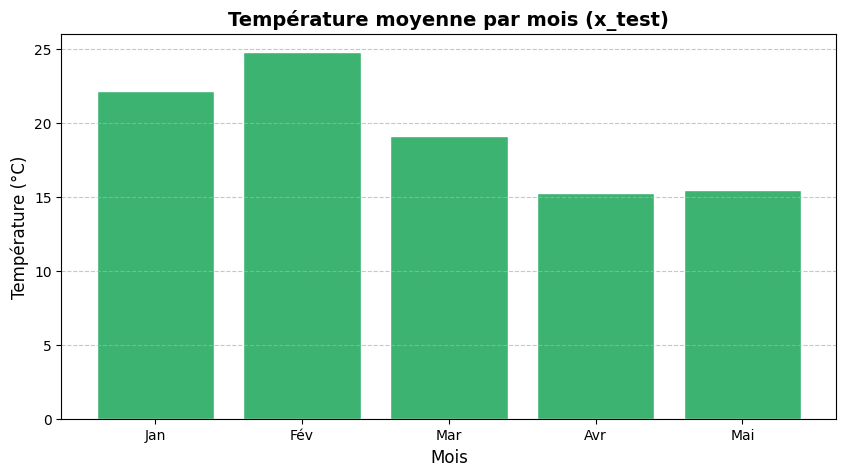

In [26]:
df_temp = x_test["Temperature"]

month_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

# Moyenne par mois
monthly = x_test.groupby('month_of_year')['Temperature'].mean().reindex(range(1,13))

plt.figure(figsize=(10,5))
plt.bar(month_labels, monthly.values, color='mediumseagreen', edgecolor='white')
plt.title('Température moyenne par mois (x_test)', fontsize=14, fontweight='bold')
plt.xlabel('Mois', fontsize=12)
plt.ylabel('Température (°C)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('../DataViz/Temperature_moyenne_par_mois(x_test).png', dpi=150, bbox_inches='tight')
plt.show()

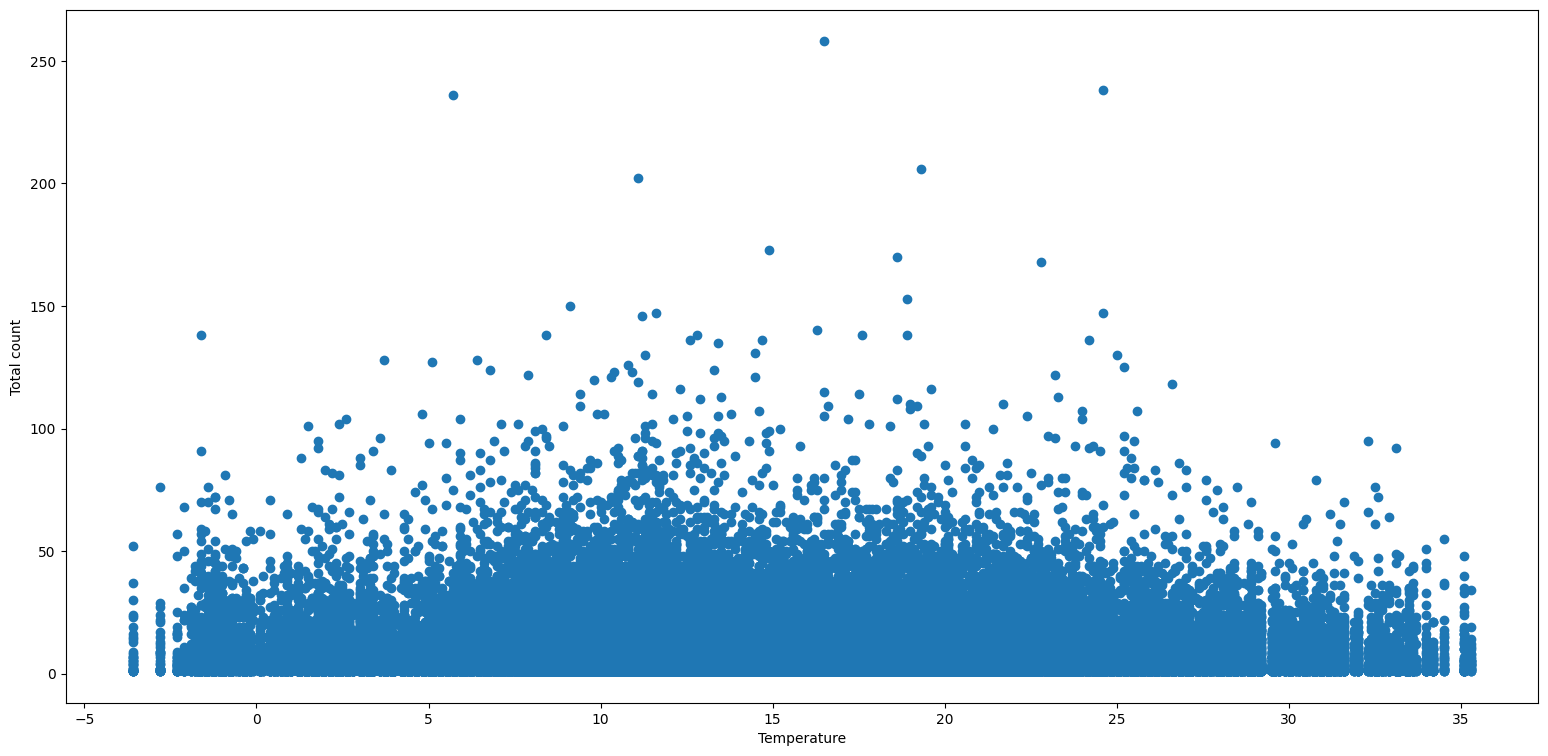

In [19]:
xpoints = x_train["Temperature"].head(100000)
ypoints = x_train["total_count"].head(100000)

plt.figure(figsize=(19,9))

plt.plot(xpoints,ypoints , 'o')
plt.xlabel("Temperature")
plt.ylabel("Total count")
plt.show()

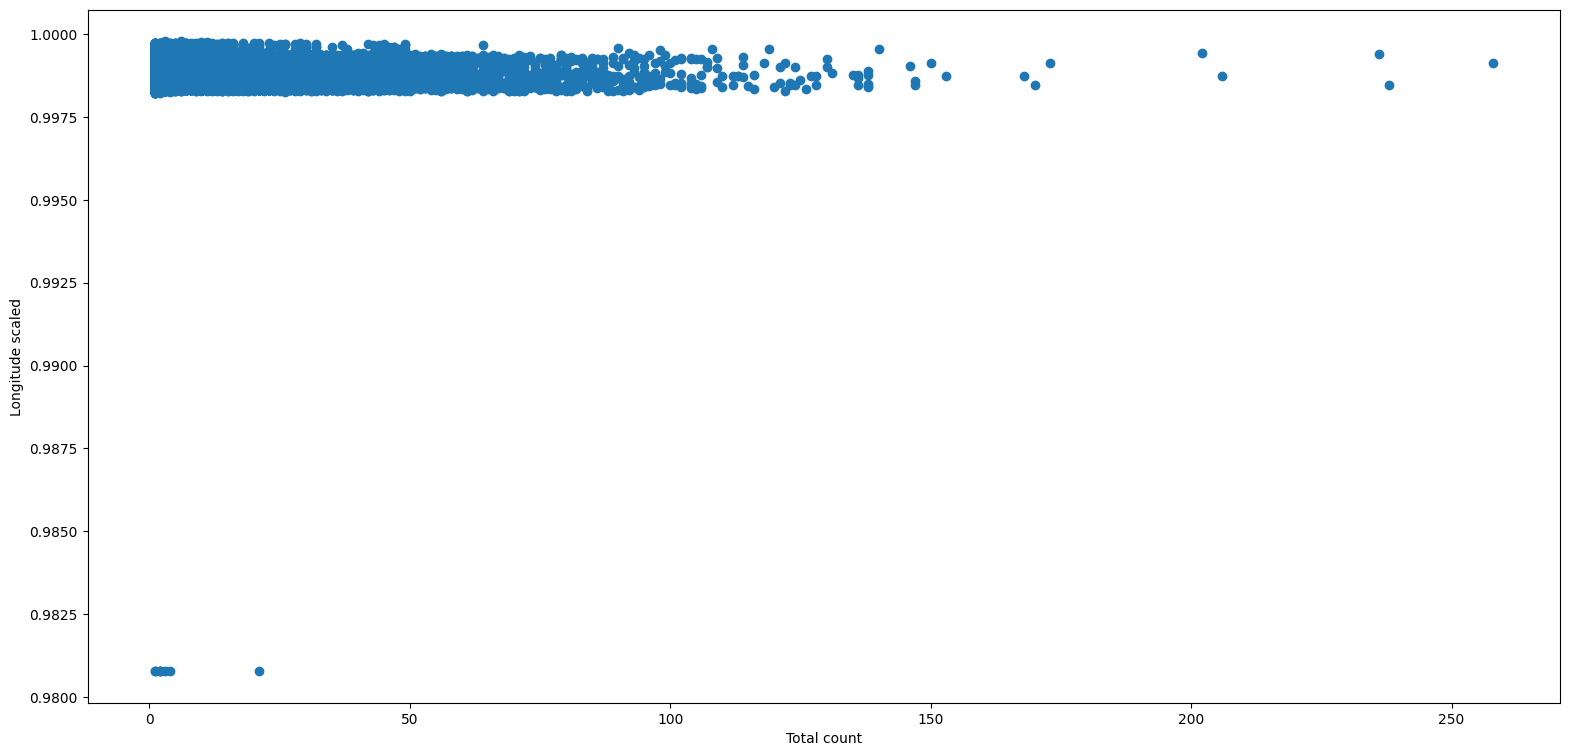

In [11]:
xpoints = x_train["total_count"].head(100000)
ypoints = x_train["longitude_scaled"].head(100000)

plt.figure(figsize=(19,9))

plt.plot(xpoints,ypoints , 'o')
plt.xlabel("Total count")
plt.ylabel("Longitude scaled")
plt.show()

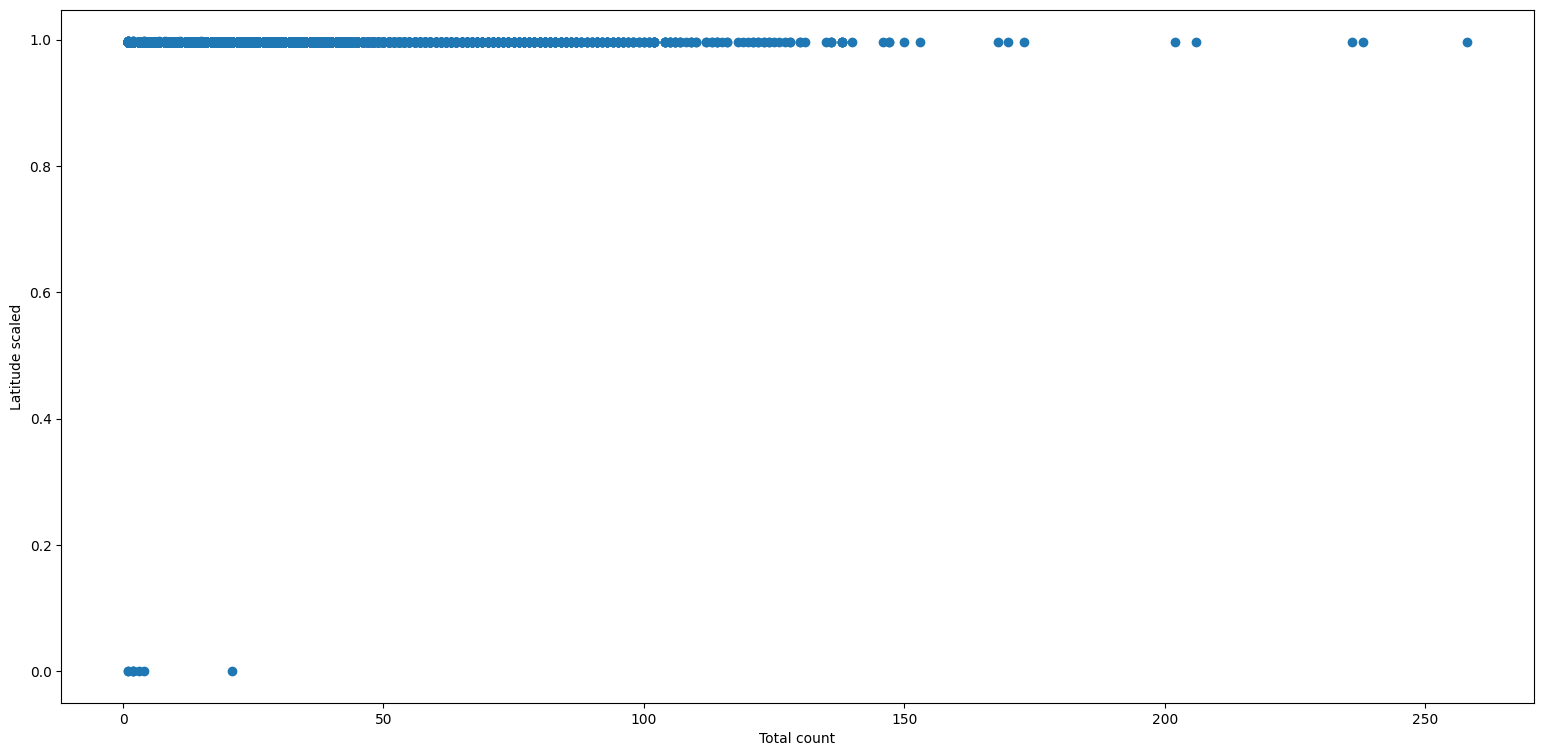

In [13]:
xpoints = x_train["total_count"].head(100000)
ypoints = x_train["latitude_scaled"].head(100000)

plt.figure(figsize=(19,9))

plt.plot(xpoints,ypoints , 'o')
plt.xlabel("Total count")
plt.ylabel("Latitude scaled")
plt.show()

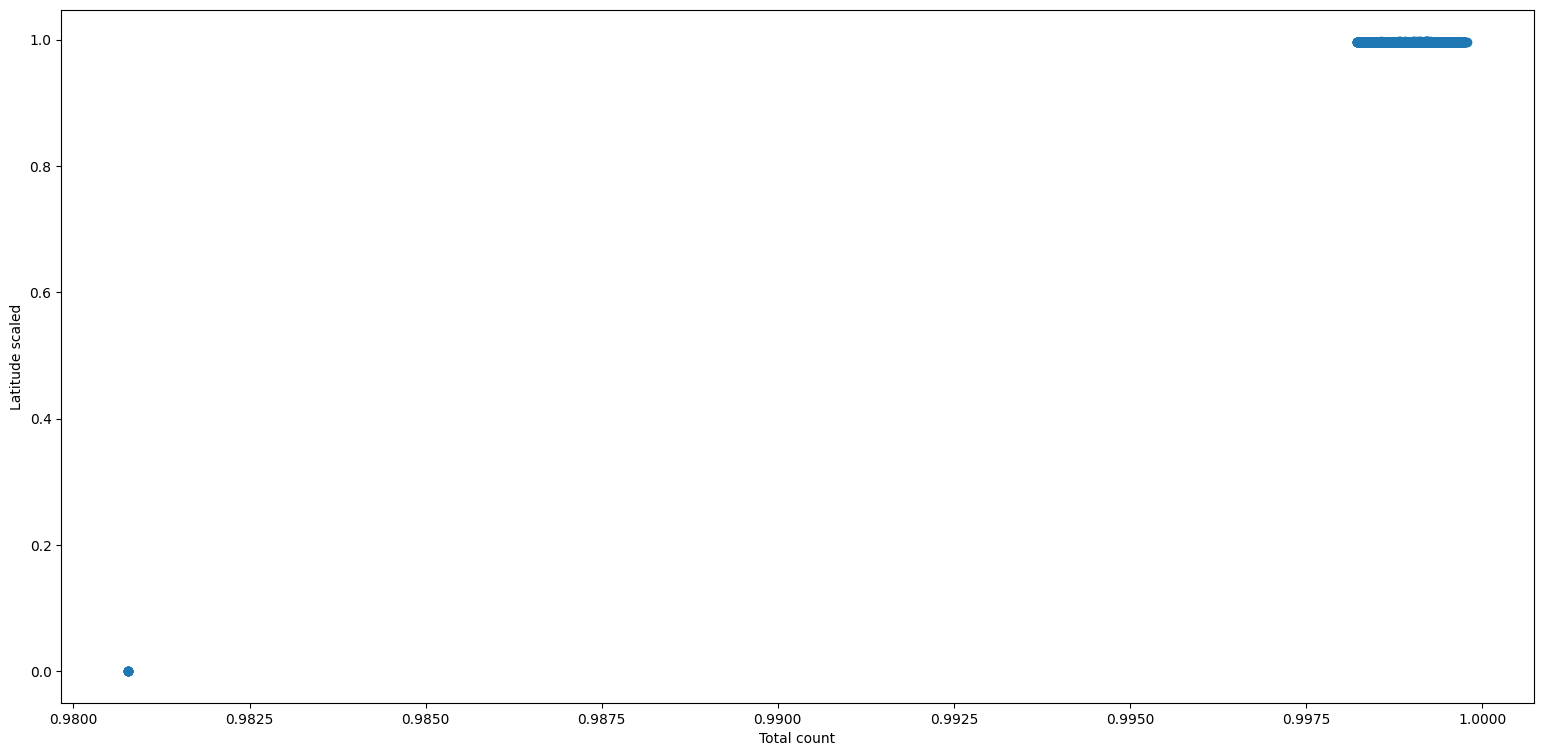

In [15]:
xpoints = x_train["longitude_scaled"].head(100000)
ypoints = x_train["latitude_scaled"].head(100000)

plt.figure(figsize=(19,9))

plt.plot(xpoints,ypoints , 'o')
plt.xlabel("Total count")
plt.ylabel("Latitude scaled")
plt.show()